##Dataset Merging

In [ ]:
import os
import shutil

base = "/content/drive/MyDrive/C-NMC"
new_dataset = "/content/CNMC"

os.makedirs(new_dataset + "/all", exist_ok=True)
os.makedirs(new_dataset + "/hem", exist_ok=True)

for fold in os.listdir(base):
    fold_path = os.path.join(base, fold)

    if os.path.isdir(fold_path):
        for cls in os.listdir(fold_path):
            class_path = os.path.join(fold_path, cls)

            for img in os.listdir(class_path):
                src = os.path.join(class_path, img)
                dst = os.path.join(new_dataset, cls, img)

                shutil.copy(src, dst)

print("Dataset merged successfully!")

Dataset merged successfully!


In [ ]:
import os

base = "/content/CNMC_Subset"

folders = [
    "train/all", "train/hem",
    "val/all", "val/hem",
    "test/all", "test/hem"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

print("Folders ready")

Folders ready


##Create Subset of Dataset (Considered 4200 images)

In [ ]:
import os
import random
import shutil

source_all = "/content/CNMC/all"
source_hem = "/content/CNMC/hem"

dest = "/content/CNMC_Subset"

def split_copy(source, cls):

    images = os.listdir(source)
    random.shuffle(images)

    train = images[:1500]
    val = images[1500:1800]
    test = images[1800:2100]

    for img in train:
        shutil.copy(
            os.path.join(source, img),
            os.path.join(dest, "train", cls, img)
        )

    for img in val:
        shutil.copy(
            os.path.join(source, img),
            os.path.join(dest, "val", cls, img)
        )

    for img in test:
        shutil.copy(
            os.path.join(source, img),
            os.path.join(dest, "test", cls, img)
        )

split_copy(source_all, "all")
split_copy(source_hem, "hem")

print("4200 dataset created")

4200 dataset created


##Import Necessary Libraries and Set Dataset Path

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
train_path = "/content/CNMC_Subset/train"
val_path = "/content/CNMC_Subset/val"
test_path = "/content/CNMC_Subset/test"

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2],
    vertical_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(300, 300),
    batch_size=32, # Increased for stability
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 3000 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


##Load the EfficientNetB3 Model

In [ ]:
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(300, 300, 3))
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

## Compile and Train the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

def weighted_binary_crossentropy(pos_weight):
    def loss(y_true, y_pred):
        return K.mean(-(pos_weight*y_true*K.log(y_pred + 1e-7) + (1-y_true)*K.log(1-y_pred + 1e-7)))
    return loss

pos_weight = 1.5
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=weighted_binary_crossentropy(pos_weight),
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.5610 - loss: 1.2004 - val_accuracy: 0.6217 - val_loss: 0.8593 - learning_rate: 1.0000e-05
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 77s 823ms/step - accuracy: 0.6027 - loss: 1.1185 - val_accuracy: 0.6900 - val_loss: 0.7865 - learning_rate: 1.0000e-05
Epoch 3/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 859ms/step - accuracy: 0.6413 - loss: 1.0265 - val_accuracy: 0.7333 - val_loss: 0.7237 - learning_rate: 1.0000e-05
Epoch 4/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 845ms/step - accuracy: 0.6463 - loss: 1.0140 - val_accuracy: 0.7433 - val_loss: 0.7140 - learning_rate: 1.0000e-05
Epoch 5/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 865ms/step - accuracy: 0.6497 - loss: 1.0028 - val_accuracy: 0.7483 - val_loss: 0.7202 - learning_rate: 1.0000e-05
Epoch 6/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 864ms/step - accuracy: 0.6653 - loss: 0.9640 - val_accuracy: 0.7567 - val_loss: 0.7392 - learning_rate: 1.0000e-05
Epoch 7/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 912ms/step - accur

##Plot Accuracy and Loss (Train vs Val.)

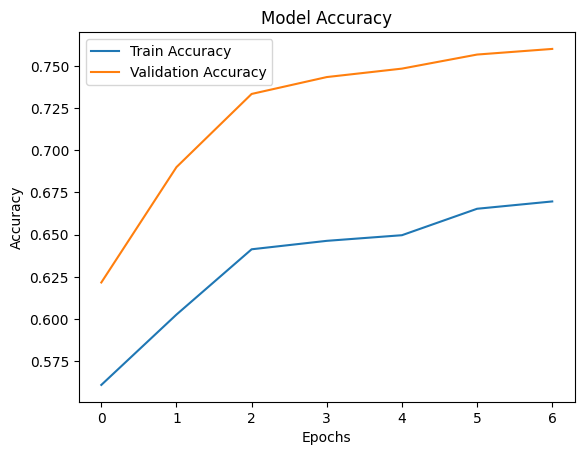

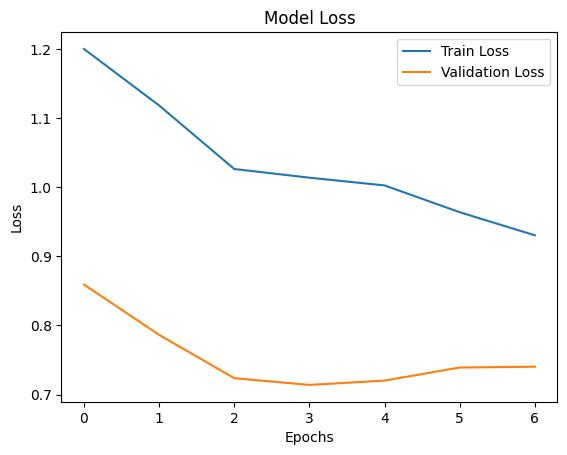

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

##Test Accuracy

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.7350 - loss: 0.5621
Test Accuracy: 0.7350000143051147


## Confusion Matrix

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 787ms/step


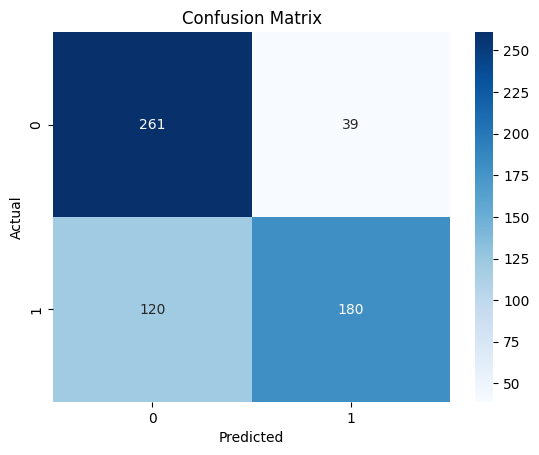

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()